<a href="https://colab.research.google.com/github/didacuscha/Maths_for_AI/blob/main/Ejercicios_adicionales_semana4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem 1: Convexity of a Ball in $\mathbb{R}^n$

**Problem Statement (Translated):**
Consider the following set defined as $B(w, r) = \{x \in \mathbb{R}^n : \|x - w\|_2 \le r\}$. This set corresponds to all points in $\mathbb{R}^n$ that are inside the ball of radius $r > 0$ around the fixed point $w \in \mathbb{R}^n$. Determine if this set is convex or not.

**Hint:** Use the triangle inequality property of the norm. That is, use the fact that $\|x + y\|_2 \le \|x\|_2 + \|y\|_2$ for all $x, y \in \mathbb{R}^n$.

**Mathematical Proof:**

To determine if the set $B(w, r)$ is convex, we need to check if for any two points $x_1, x_2 \in B(w, r)$, the line segment connecting them is also entirely contained within $B(w, r)$.

Let $x_1, x_2 \in B(w, r)$. By definition, this means:
1. $\|x_1 - w\|_2 \le r$
2. $\|x_2 - w\|_2 \le r$

Consider an arbitrary point $x$ on the line segment connecting $x_1$ and $x_2$. This point can be represented as:
$x = \lambda x_1 + (1 - \lambda) x_2$, where $0 \le \lambda \le 1$.

We need to show that this point $x$ also belongs to $B(w, r)$, i.e., we need to show that $\|x - w\|_2 \le r$.

Let's calculate the norm $\|x - w\|_2$:
$$ \|x - w\|_2 = \|\lambda x_1 + (1 - \lambda) x_2 - w\|_2 $$
We can rewrite $w$ as $\lambda w + (1 - \lambda) w$:
$$ \|x - w\|_2 = \|\lambda x_1 + (1 - \lambda) x_2 - (\lambda w + (1 - \lambda) w)\|_2 $$
Rearranging the terms:
$$ \|x - w\|_2 = \|\lambda (x_1 - w) + (1 - \lambda) (x_2 - w)\|_2 $$
Now, we apply the triangle inequality $\|a + b\|_2 \le \|a\|_2 + \|b\|_2$, where $a = \lambda (x_1 - w)$ and $b = (1 - \lambda) (x_2 - w)$:
$$ \|x - w\|_2 \le \|\lambda (x_1 - w)\|_2 + \|(1 - \lambda) (x_2 - w)\|_2 $$
Using the property $\|c \cdot v\|_2 = |c| \cdot \|v\|_2$, and noting that $\lambda \ge 0$ and $(1 - \lambda) \ge 0$, we get:
$$ \|x - w\|_2 \le \lambda \|x_1 - w\|_2 + (1 - \lambda) \|x_2 - w\|_2 $$
Since we know $\|x_1 - w\|_2 \le r$ and $\|x_2 - w\|_2 \le r$:
$$ \|x - w\|_2 \le \lambda r + (1 - \lambda) r $$
$$ \|x - w\|_2 \le \lambda r + r - \lambda r $$
$$ \|x - w\|_2 \le r $$
Since $\|x - w\|_2 \le r$, the point $x = \lambda x_1 + (1 - \lambda) x_2$ belongs to the set $B(w, r)$ for any $0 \le \lambda \le 1$.

**Conclusion:** The set $B(w, r)$ (a closed ball in $\mathbb{R}^n$) is a convex set.

**Visualization (in 2D):**
We can visualize this by plotting a circle (the boundary of the ball in 2D), picking two points inside it, and drawing the line segment between them. We expect the segment to remain entirely within the circle.

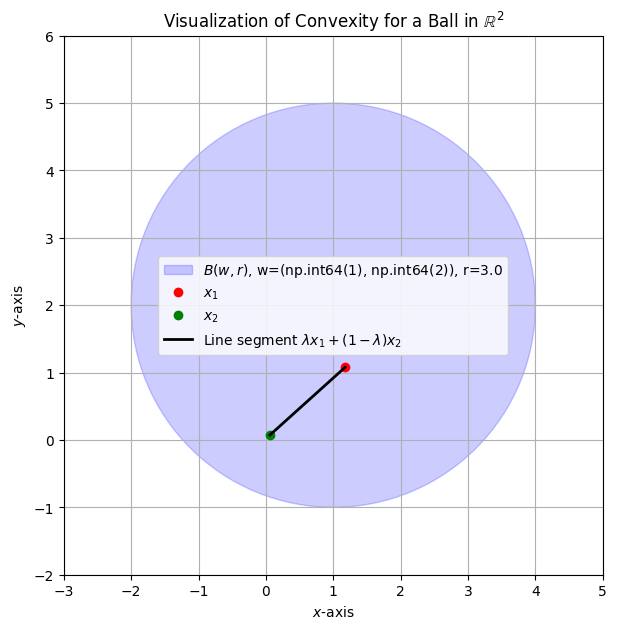

Center w: [1 2]
Radius r: 3.0
Point x1: [1.1754877  1.07865091] (Norm ||x1-w|| = 0.9379 <= 3.0)
Point x2: [0.05874981 0.07255482] (Norm ||x2-w|| = 2.1450 <= 3.0)
Midpoint: [0.61711875 0.57560287] (Norm ||midpoint-w|| = 1.4750 <= 3.0)


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters for the Ball B(w, r) in 2D ---
w = np.array([1, 2])  # Center of the ball
r = 3.0              # Radius of the ball
n = 2                # Dimension (for visualization, n=2)

# --- Create the plot ---
fig, ax = plt.subplots(figsize=(7, 7))

# Plot the ball (circle in 2D)
circle = plt.Circle(w, r, color='blue', alpha=0.2, label=f'$B(w, r)$, w={tuple(w)}, r={r}')
ax.add_patch(circle)

# --- Select two random points inside the ball ---
# Generate points within a square and keep only those inside the circle
points_generated = 0
x1, x2 = None, None

while x1 is None:
    p = np.random.rand(n) * 2 * r + (w - r) # Random point in bounding box
    if np.linalg.norm(p - w) <= r:
        x1 = p

while x2 is None:
    p = np.random.rand(n) * 2 * r + (w - r) # Random point in bounding box
    if np.linalg.norm(p - w) <= r:
        x2 = p

# --- Plot the points and the line segment ---
ax.plot(x1[0], x1[1], 'ro', label='$x_1$')
ax.plot(x2[0], x2[1], 'go', label='$x_2$')

# Generate points for the line segment: x = lambda*x1 + (1-lambda)*x2
lambdas = np.linspace(0, 1, 50)
segment_x = [l * x1[0] + (1 - l) * x2[0] for l in lambdas]
segment_y = [l * x1[1] + (1 - l) * x2[1] for l in lambdas]
ax.plot(segment_x, segment_y, 'k-', linewidth=2, label='Line segment $\lambda x_1 + (1-\lambda) x_2$')

# --- Plot settings ---
ax.set_xlabel('$x$-axis')
ax.set_ylabel('$y$-axis')
ax.set_title('Visualization of Convexity for a Ball in $\mathbb{R}^2$')
ax.set_aspect('equal', adjustable='box') # Ensure the circle looks like a circle
ax.legend()
ax.grid(True)

# Adjust plot limits to see the ball clearly
ax.set_xlim(w[0] - r - 1, w[0] + r + 1)
ax.set_ylim(w[1] - r - 1, w[1] + r + 1)

plt.show()

print(f"Center w: {w}")
print(f"Radius r: {r}")
print(f"Point x1: {x1} (Norm ||x1-w|| = {np.linalg.norm(x1-w):.4f} <= {r})")
print(f"Point x2: {x2} (Norm ||x2-w|| = {np.linalg.norm(x2-w):.4f} <= {r})")
# Verify a midpoint (lambda=0.5) is inside
midpoint = 0.5 * x1 + 0.5 * x2
print(f"Midpoint: {midpoint} (Norm ||midpoint-w|| = {np.linalg.norm(midpoint-w):.4f} <= {r})")

## Problem 2: Convexity of $f(x) = |x|$

**Problem Statement (Translated):**
Determine if the function $f(x) = |x|$ is convex, for all $x \in \mathbb{R}$. Note that this function is not differentiable at $x=0$, so we cannot use the verification through the Hessian matrix.

**Hint:** Use the triangle inequality property of the absolute value.

**Mathematical Proof:**

A function $f: D \to \mathbb{R}$ defined on a convex domain $D$ is convex if, for any $x_1, x_2 \in D$ and any $\lambda$ such that $0 \le \lambda \le 1$, the following inequality (Jensen's inequality) holds:
$$ f(\lambda x_1 + (1 - \lambda) x_2) \le \lambda f(x_1) + (1 - \lambda) f(x_2) $$

In this case, $f(x) = |x|$ and the domain is $D = \mathbb{R}$, which is a convex set.
Let $x_1, x_2 \in \mathbb{R}$ and $0 \le \lambda \le 1$. We need to check if:
$$ |\lambda x_1 + (1 - \lambda) x_2| \le \lambda |x_1| + (1 - \lambda) |x_2| $$

We know the standard triangle inequality for absolute values: $|a + b| \le |a| + |b|$.
Let $a = \lambda x_1$ and $b = (1 - \lambda) x_2$. Applying the triangle inequality:
$$ |\lambda x_1 + (1 - \lambda) x_2| \le |\lambda x_1| + |(1 - \lambda) x_2| $$
Using the property $|c \cdot y| = |c| \cdot |y|$, and noting that $\lambda \ge 0$ and $(1 - \lambda) \ge 0$, we have $|\lambda| = \lambda$ and $|1 - \lambda| = 1 - \lambda$. Therefore:
$$ |\lambda x_1| + |(1 - \lambda) x_2| = \lambda |x_1| + (1 - \lambda) |x_2| $$
Combining the steps, we get:
$$ |\lambda x_1 + (1 - \lambda) x_2| \le \lambda |x_1| + (1 - \lambda) |x_2| $$
This is exactly Jensen's inequality for $f(x) = |x|$.

**Conclusion:** The function $f(x) = |x|$ is convex on $\mathbb{R}$.

**Visualization:**
We can visualize this by plotting the function $f(x)=|x|$. For any two points on the graph, the line segment connecting them (the secant line) should lie above or on the graph of the function itself.

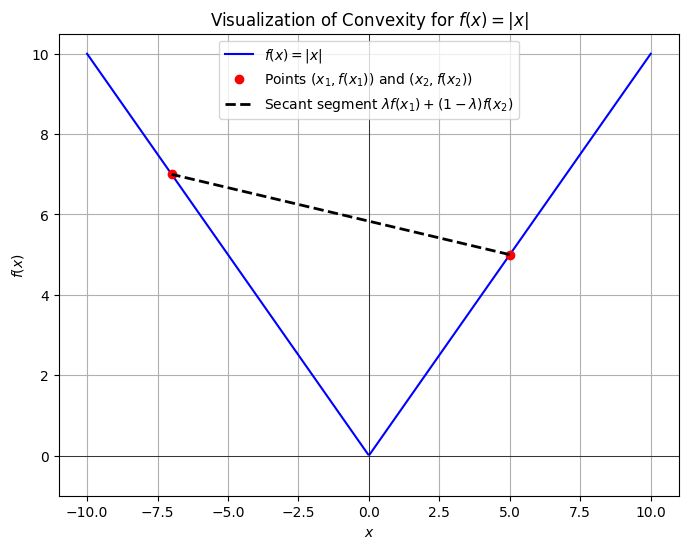

Chosen points: x1 = -7.0, x2 = 5.0
Lambda = 0.5
Interpolated x: lambda*x1 + (1-lambda)*x2 = -1.0
f(lambda*x1 + (1-lambda)*x2) = f(-1.0) = 1.0000
lambda*f(x1) + (1-lambda)*f(x2) = 0.5*|-7.0| + 0.5*|5.0| = 6.0000
Is f(interp_x) <= interp_f ? True


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function
def f(x):
  return np.abs(x)

# Generate x values for plotting the function
x_vals = np.linspace(-10, 10, 400)
y_vals = f(x_vals)

# Choose two points x1 and x2
x1 = -7.0
x2 = 5.0

# Calculate corresponding y values (on the function graph)
y1 = f(x1)
y2 = f(x2)

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the function f(x) = |x|
ax.plot(x_vals, y_vals, 'b-', label='$f(x) = |x|$')

# Plot the two points on the function graph
ax.plot([x1, x2], [y1, y2], 'ro', label=f'Points $(x_1, f(x_1))$ and $(x_2, f(x_2))$')

# Plot the secant line segment connecting the two points
# Equation of the line: y = y1 + ( (y2-y1)/(x2-x1) ) * (x - x1)
# Or parametrically: (lambda*x1 + (1-lambda)*x2, lambda*y1 + (1-lambda)*y2)
lambdas = np.linspace(0, 1, 50)
segment_x = [l * x1 + (1 - l) * x2 for l in lambdas]
segment_y = [l * y1 + (1 - l) * y2 for l in lambdas]
ax.plot(segment_x, segment_y, 'k--', linewidth=2, label='Secant segment $\lambda f(x_1) + (1-\lambda) f(x_2)$')

# --- Plot settings ---
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('Visualization of Convexity for $f(x) = |x|$')
ax.legend()
ax.grid(True)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
plt.ylim(bottom=-1) # Ensure origin is visible

plt.show()

# Verify Jensen's inequality for a midpoint (lambda = 0.5)
lambda_val = 0.5
x_interp = lambda_val * x1 + (1 - lambda_val) * x2
f_x_interp = f(x_interp)
interp_f = lambda_val * f(x1) + (1 - lambda_val) * f(x2)

print(f"Chosen points: x1 = {x1}, x2 = {x2}")
print(f"Lambda = {lambda_val}")
print(f"Interpolated x: lambda*x1 + (1-lambda)*x2 = {x_interp}")
print(f"f(lambda*x1 + (1-lambda)*x2) = f({x_interp}) = {f_x_interp:.4f}")
print(f"lambda*f(x1) + (1-lambda)*f(x2) = {lambda_val}*|{x1}| + {1-lambda_val}*|{x2}| = {interp_f:.4f}")
print(f"Is f(interp_x) <= interp_f ? {f_x_interp <= interp_f}")